<a href="https://colab.research.google.com/github/ashuwebdevloper/BAsicProjects/blob/main/Project%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

Data Collection and Processing

In [32]:
gold_data = pd.read_csv('/content/gld_price_data.csv')

In [33]:
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [34]:
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [35]:
gold_data.shape

(2290, 6)

In [36]:
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [37]:
# checking the number of missing values
gold_data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [38]:
# getting the statistical measures of the data
gold_data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Correlation:
1. Positive Correlation
2. Negative Correlation

In [39]:
correlation = gold_data.drop('Date', axis=1).corr()

<Axes: >

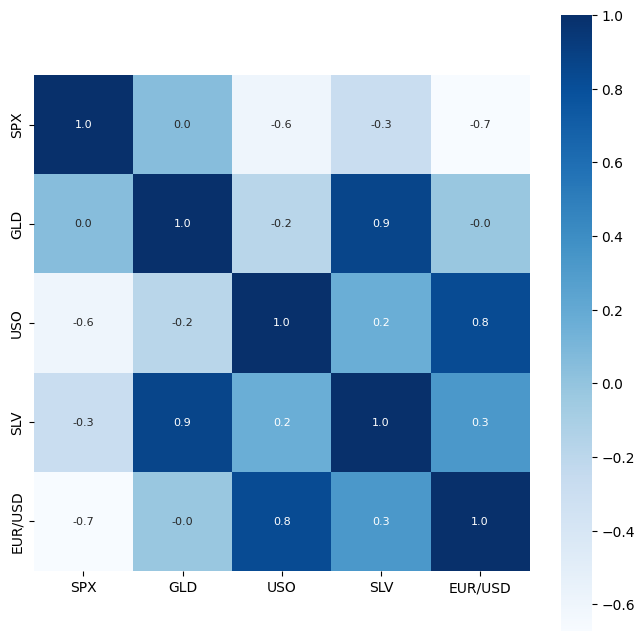

In [40]:
# constructing a heatmap to understand the correlatiom
plt.figure(figsize = (8,8))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f',annot=True, annot_kws={'size':8}, cmap='Blues')

In [41]:
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


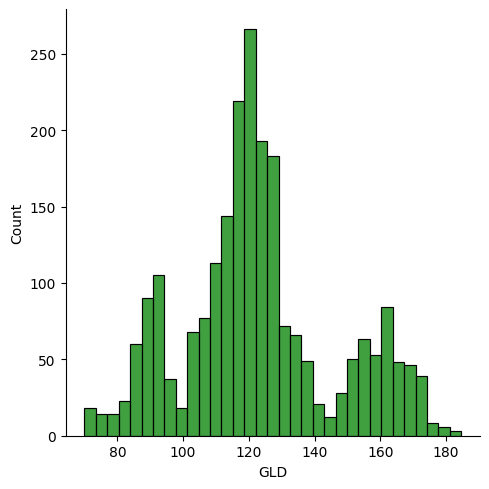

In [42]:
sns.displot(gold_data['GLD'],color = 'green')

Spliting the Features ad target

In [43]:
X = gold_data.drop(['Date','GLD'],axis=1)
Y = gold_data['GLD']

In [44]:
print(X)
print(Y)

              SPX        USO      SLV   EUR/USD
0     1447.160034  78.470001  15.1800  1.471692
1     1447.160034  78.370003  15.2850  1.474491
2     1411.630005  77.309998  15.1670  1.475492
3     1416.180054  75.500000  15.0530  1.468299
4     1390.189941  76.059998  15.5900  1.557099
...           ...        ...      ...       ...
2285  2671.919922  14.060000  15.5100  1.186789
2286  2697.790039  14.370000  15.5300  1.184722
2287  2723.070068  14.410000  15.7400  1.191753
2288  2730.129883  14.380000  15.5600  1.193118
2289  2725.780029  14.405800  15.4542  1.182033

[2290 rows x 4 columns]
0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64


Spliting into test and train data set

In [45]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.2,random_state=2)

Model Training : Random Forest Regressor  

In [46]:
regressor = RandomForestRegressor(n_estimators=100)

In [47]:
# training the model
regressor.fit(X_train,Y_train)

RandomForestRegressor()

Model Evaluvation

In [48]:
test_data_prediction = regressor.predict(X_test)

In [49]:
print(test_data_prediction)

[168.7589995   81.98559998 116.11139992 127.77170043 120.89100121
 154.50819778 150.24619804 126.01660047 117.47849865 125.89070069
 116.6192009  171.6359006  141.5077988  167.71849821 115.21580007
 117.86520032 140.68220321 170.36050098 159.42560295 159.79699956
 155.14369988 124.78510041 175.8755     157.26280366 125.23130008
  93.79739953  77.95559986 120.4287001  119.17659939 167.39700024
  88.23200068 125.11759997  91.15720083 117.61000025 121.12049968
 136.53960211 115.48510114 115.0715006  146.83949985 107.03030132
 103.98660235  87.21089802 126.49580061 117.5769996  155.18789871
 119.5395003  108.35739966 108.07009815  93.13500078 127.34559721
  75.25169995 113.63469921 121.18749996 111.32669923 119.01759917
 120.68759953 158.75669916 167.88550152 147.00259689  85.36949849
  94.11730047  86.79409866  90.59409987 118.99810082 126.50070078
 127.58950001 170.47359956 122.23589935 117.37569911  98.36269998
 168.64270175 143.34959906 132.18050173 121.20890237 120.97149926
 119.62580

In [50]:
# R squared error
error_score = metrics.r2_score(Y_test,test_data_prediction)
print("R Squared error :"  , error_score)

R Squared error : 0.9889173087815534


Compare the actual value and prediccted value

In [51]:
Y_test = list(Y_test)

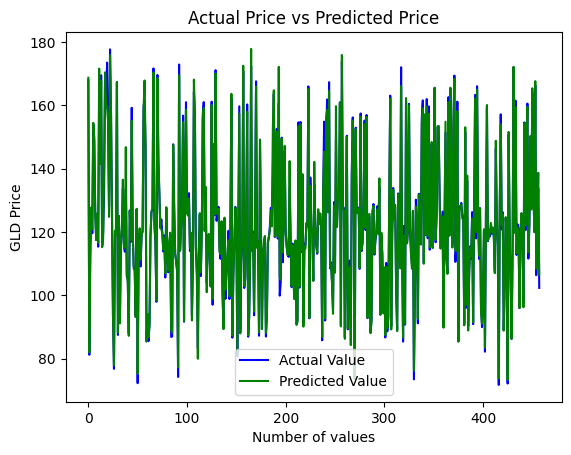

In [52]:
plt.plot(Y_test, color='blue', label = 'Actual Value')
plt.plot(test_data_prediction, color='green', label='Predicted Value')
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Number of values')
plt.ylabel('GLD Price')
plt.legend()
plt.show()